In [1]:
import torch
import torch.nn as nn

In [2]:
torch.manual_seed(123)

In [3]:
VERSION = "v1"
DEVICE = torch.device("cpu")

### Encoding

In [4]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

In [5]:
TOK_EOT = "<|endoftext|>"
TOK_ID_EOT = tokenizer.encode(TOK_EOT, allowed_special={TOK_EOT})[0]


In [6]:
from dataclasses import dataclass, asdict

@dataclass
class Config:
    name: str
    vocab_size: int
    batch_size: int
    n_heads: int
    n_layers: int
    emb_dim: int
    hid_dim: int
    context_length: int  = 1024
    drop_rate: float     = 0.1
    qkv_bias: bool       = False

In [7]:
GPT_CONFIG_SM = Config(
    name            = "small",
    vocab_size      = tokenizer.n_vocab,
    batch_size      = 4,
    emb_dim         = 768,
    hid_dim         = 768,
    n_layers        = 12,
    n_heads         = 12,
)

In [8]:
GPT_CONFIG_MD = Config(
    name            = "medium",
    vocab_size      = tokenizer.n_vocab,
    batch_size      = 2,
    emb_dim         = 1024,
    hid_dim         = 1024,
    n_layers        = 24,
    n_heads         = 16,
)

In [9]:
GPT_CONFIG_LG = Config(
    name            = "large",
    vocab_size      = tokenizer.n_vocab,
    batch_size      = 1,
    emb_dim         = 1280,
    hid_dim         = 1280,
    n_layers        = 36,
    n_heads         = 20,
)

In [10]:
GPT_CONFIG_XL = Config(
    name            = "xlarge",
    vocab_size      = tokenizer.n_vocab,
    batch_size      = 1,
    emb_dim         = 1600,
    hid_dim         = 1600,
    n_layers        = 48,
    n_heads         = 25,
)

In [11]:
cfg = asdict(GPT_CONFIG_SM)
cfg

{'name': 'small',
 'vocab_size': 50257,
 'batch_size': 4,
 'n_heads': 12,
 'n_layers': 12,
 'emb_dim': 768,
 'hid_dim': 768,
 'context_length': 1024,
 'drop_rate': 0.1,
 'qkv_bias': False}

In [12]:
from pathlib import Path

FOLDER = Path("weights")
FOLDER.mkdir(parents=True, exist_ok=True)

FILE = FOLDER / f"{VERSION}-{cfg["name"]}.pt"
FILE

PosixPath('weights/v1-small.pt')

In [13]:
text = "hello, world"

tokens_ids = tokenizer.encode(text, allowed_special={TOK_EOT})
tokens_ids

[31373, 11, 995]

In [14]:
tokenizer.decode(tokens_ids)

'hello, world'

In [15]:
from torch.utils.data import Dataset

class GPTDataset(Dataset):
    def __init__(self, text, tokenizer, max_len, stride):
        inputs_ids = []
        target_ids = []
        tokens_ids = tokenizer.encode(text, allowed_special={TOK_EOT})
        max_len = min(max_len, len(tokens_ids) - 1)

        for i in range(0, len(tokens_ids) - max_len, stride):
            inputs_ids.append(tokens_ids[i:i+max_len])
            target_ids.append(tokens_ids[i+1:i+max_len+1])

        self.inputs_ids = torch.tensor(inputs_ids)
        self.target_ids = torch.tensor(target_ids)

    def __len__(self):
        return len(self.inputs_ids)

    def __getitem__(self, index):
        return self.inputs_ids[index], self.target_ids[index]

In [16]:
from torch.utils.data import DataLoader

def create_dataloader(text, batch_size: int = 4, max_len = 256, stride = 128, shuffle = True, drop_last = True, num_workers = 0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDataset(text, tokenizer, max_len, stride)
    dataloader = DataLoader(
        dataset,
        batch_size,
        shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )
    return dataloader

In [17]:
with open('the-verdict.txt', mode='r', encoding='utf-8') as f:
    text = f.read()

dataloader = create_dataloader(text, batch_size=cfg["batch_size"], max_len=cfg["context_length"], stride=cfg["context_length"] // 2, shuffle=False)
dataloader

In [18]:
data_iter = iter(dataloader)
data_batch = next(data_iter)

In [19]:
inputs_ids, target_ids = data_batch
inputs_ids

tensor([[   40,   367,  2885,  ...,   691, 12226,   318],
        [  271, 10899,   550,  ..., 19217, 24887, 13431],
        [  284,  1234,  8737,  ...,   402,   271, 10899],
        [   13,   198,   198,  ...,   286,   340,   477]])

In [20]:
tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
tok_emb

Embedding(50257, 768)

In [21]:
tok_embeddings = tok_emb(inputs_ids)
tok_embeddings

tensor([[[ 0.5009, -0.6654, -0.7507,  ..., -1.0479, -0.3402,  0.0413],
         [-0.9438,  0.6965, -1.0856,  ..., -0.9003,  0.2704,  0.4577],
         [-1.0402,  2.2702, -0.5748,  ..., -1.5384, -0.4958, -0.1905],
         ...,
         [ 1.7429,  0.2175, -1.8387,  ..., -0.8041,  0.0440, -1.4285],
         [-0.3899, -0.6600, -0.0901,  ..., -0.1237, -0.4820,  0.9703],
         [-1.5268, -0.2618,  0.4808,  ..., -1.1754, -0.4870,  0.6056]],

        [[ 1.3024, -0.4527,  0.1296,  ..., -1.5370,  0.0957,  0.1539],
         [ 0.5066,  0.1970, -0.9912,  ...,  0.8015, -1.2639, -0.4357],
         [ 0.7125, -0.6415, -0.9959,  ..., -0.6479, -0.3409, -0.6546],
         ...,
         [-0.7095, -0.9720, -0.2731,  ...,  0.8578, -0.6572,  0.1900],
         [-0.3929, -0.8800,  0.9083,  ...,  0.3457, -0.7534,  0.7546],
         [-0.1066, -0.9557,  0.1733,  ...,  1.0202, -1.8725,  0.9896]],

        [[ 0.3916,  1.2535,  1.5891,  ...,  1.1084,  2.0499, -0.4095],
         [ 0.7508,  0.3348, -0.3150,  ..., -0

In [22]:
pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
pos_emb

Embedding(1024, 768)

In [23]:
pos_embeddings = pos_emb(torch.arange(0, cfg["context_length"]))
pos_embeddings

tensor([[ 0.8441, -0.5089,  0.3452,  ...,  1.7957,  1.5421,  0.3268],
        [ 1.2459, -0.2169,  0.8214,  ..., -1.5197, -1.3070,  0.5905],
        [ 0.9077,  1.5500,  0.7187,  ..., -2.2225, -1.9496, -0.2411],
        ...,
        [-1.1472,  1.6019,  0.6759,  ..., -0.5483,  0.6498,  0.4377],
        [-1.3375, -0.5155, -1.5364,  ...,  1.7783,  0.0736,  1.1416],
        [ 0.8395,  1.1807,  1.2811,  ...,  2.3671, -0.6198, -0.5429]],
       grad_fn=<EmbeddingBackward0>)

In [24]:
inputs_embeddings = tok_embeddings + pos_embeddings
inputs_embeddings

tensor([[[ 1.3451, -1.1743, -0.4055,  ...,  0.7479,  1.2019,  0.3681],
         [ 0.3022,  0.4796, -0.2641,  ..., -2.4201, -1.0367,  1.0482],
         [-0.1325,  3.8202,  0.1438,  ..., -3.7610, -2.4454, -0.4315],
         ...,
         [ 0.5956,  1.8195, -1.1629,  ..., -1.3523,  0.6938, -0.9908],
         [-1.7274, -1.1755, -1.6264,  ...,  1.6545, -0.4084,  2.1119],
         [-0.6873,  0.9188,  1.7619,  ...,  1.1917, -1.1068,  0.0627]],

        [[ 2.1465, -0.9616,  0.4747,  ...,  0.2587,  1.6378,  0.4807],
         [ 1.7526, -0.0198, -0.1697,  ..., -0.7182, -2.5709,  0.1548],
         [ 1.6202,  0.9085, -0.2773,  ..., -2.8705, -2.2906, -0.8956],
         ...,
         [-1.8567,  0.6299,  0.4028,  ...,  0.3095, -0.0074,  0.6277],
         [-1.7304, -1.3954, -0.6280,  ...,  2.1240, -0.6798,  1.8962],
         [ 0.7329,  0.2250,  1.4544,  ...,  3.3873, -2.4922,  0.4466]],

        [[ 1.2357,  0.7446,  1.9342,  ...,  2.9041,  3.5920, -0.0826],
         [ 1.9967,  0.1179,  0.5064,  ..., -1

### Attention

In [25]:
class SelfAttention(nn.Module):
    def __init__(self, d_in: int, d_out: int, qkv_bias: bool = False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        q = self.W_query(x)
        k = self.W_key(x)
        v = self.W_value(x)

        attn_scores = q @ k.transpose(1, 2)
        attn_weights = torch.softmax(attn_scores / (q.shape[-1]**0.5), dim=-1)

        context_vecs = attn_weights @ v
        return context_vecs

self_attention = SelfAttention(cfg["emb_dim"], cfg["hid_dim"], cfg["qkv_bias"])
self_attention

SelfAttention(
  (W_query): Linear(in_features=768, out_features=768, bias=False)
  (W_key): Linear(in_features=768, out_features=768, bias=False)
  (W_value): Linear(in_features=768, out_features=768, bias=False)
)

In [26]:
self_attention(inputs_embeddings)

tensor([[[ 0.1224, -0.0181, -0.0816,  ...,  0.0752,  0.0789, -0.0289],
         [-0.0300,  0.0548,  0.0079,  ...,  0.1404,  0.0945,  0.0778],
         [-0.0819,  0.0230, -0.0137,  ...,  0.0659,  0.0794,  0.1361],
         ...,
         [ 0.0327,  0.0653, -0.0443,  ...,  0.0644,  0.0712,  0.0012],
         [ 0.0425,  0.1484, -0.0299,  ...,  0.0439,  0.0978,  0.0369],
         [ 0.0358,  0.0545, -0.0383,  ...,  0.0578,  0.1303,  0.0591]],

        [[ 0.0422, -0.0427, -0.0101,  ...,  0.0998,  0.0958,  0.0532],
         [ 0.0148,  0.0544,  0.0109,  ...,  0.0661,  0.1370,  0.0396],
         [-0.0162, -0.0092, -0.0547,  ...,  0.0322,  0.0144,  0.0528],
         ...,
         [ 0.0804,  0.0674,  0.0046,  ..., -0.0135,  0.0317,  0.0528],
         [ 0.0278,  0.1419,  0.0176,  ...,  0.0706,  0.1066, -0.0818],
         [ 0.0191,  0.0334, -0.0597,  ...,  0.1009,  0.0728,  0.0205]],

        [[ 0.0013,  0.0778,  0.0571,  ...,  0.0828,  0.0532, -0.0045],
         [ 0.0294,  0.0593,  0.0368,  ...,  0

In [27]:
class CasualAttention(nn.Module):
    def __init__(self, d_in: int, d_out: int, context_len: int, qkv_bias: bool = False, drop_rate: float = 0.5):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(drop_rate, inplace=False)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_len, context_len), diagonal=1),
            persistent=True
        )

    def forward(self, x):
        b, seq_len, emb_dim = x.shape

        q = self.W_query(x)
        k = self.W_key(x)
        v = self.W_value(x)

        attn_scores = q @ k.transpose(1, 2)
        attn_scores.masked_fill_(
            self.mask.bool()[:seq_len, :seq_len],
            -torch.inf
        )
        attn_weights = self.dropout(torch.softmax(attn_scores / (q.shape[-1]**0.5), dim=-1))

        context_vecs = attn_weights @ v
        return context_vecs

casual_attention = CasualAttention(cfg["emb_dim"], cfg["hid_dim"], cfg["context_length"], cfg["qkv_bias"], cfg["drop_rate"])
casual_attention

CasualAttention(
  (W_query): Linear(in_features=768, out_features=768, bias=False)
  (W_key): Linear(in_features=768, out_features=768, bias=False)
  (W_value): Linear(in_features=768, out_features=768, bias=False)
  (dropout): Dropout(p=0.1, inplace=False)
)

In [28]:
casual_attention(inputs_embeddings)

tensor([[[ 8.9655e-01, -1.3604e+00, -1.1407e+00,  ..., -5.2872e-01,
          -3.2634e-01, -2.7961e+00],
         [ 1.2951e-01, -9.6268e-01, -1.2004e+00,  ...,  7.1204e-01,
           4.1474e-01, -1.5467e+00],
         [ 1.0103e-01, -6.7771e-01, -1.1016e+00,  ...,  1.0929e+00,
           4.9485e-01, -9.9244e-01],
         ...,
         [ 1.7525e-02, -7.0612e-02, -1.2732e-01,  ..., -1.2025e-01,
           2.0228e-02, -5.1194e-02],
         [ 1.7609e-03, -8.9680e-02, -9.4093e-02,  ..., -7.9817e-02,
           1.7760e-02,  1.0973e-02],
         [ 9.8217e-03, -1.1449e-01, -1.1086e-01,  ..., -4.2005e-02,
          -5.2316e-02, -5.7426e-02]],

        [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 8.6770e-01, -1.2859e-01,  6.5315e-02,  ..., -6.9775e-01,
           5.2733e-01, -1.8632e+00],
         [ 6.0397e-01, -2.7169e-01,  3.0960e-02,  ..., -5.7703e-01,
           4.2217e-01, -1.3168e+00],
         ...,
         [ 6.8109e-02, -7

In [29]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in: int, d_out: int, context_len: int, n_heads: int, qkv_bias: bool = False, drop_rate: float = 0.2):
        super().__init__()
        assert cfg["hid_dim"] % cfg["n_heads"] == 0, "hid_dim must be divisible by n_heads"
        self.head_dim = d_out // n_heads
        self.hid_dim = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(drop_rate)
        self.out_proj = nn.Linear(d_out, d_out)
        self.register_buffer(
            "mask",
            torch.triu(torch.zeros(context_len, context_len), diagonal=1),
            persistent=True
        )

    def forward(self, x):
        b, seq_len, emb_dim = x.shape

        q = self.W_query(x).view(b, seq_len, -1, self.head_dim).transpose(1, 2)
        k = self.W_key(x).view(b, seq_len, -1, self.head_dim).transpose(1, 2)
        v = self.W_value(x).view(b, seq_len, -1, self.head_dim).transpose(1, 2)

        attn_scores = q @ k.transpose(2, 3)
        attn_scores.masked_fill_(
            self.mask.bool()[:seq_len, :seq_len],
            -torch.inf
        )
        attn_weights = self.dropout(torch.softmax(attn_scores / (self.hid_dim**0.5), dim=-1))

        context_vecs = (attn_weights @ v).transpose(1, 2).contiguous().view(b, seq_len, -1)
        return self.out_proj(context_vecs)

In [30]:
mha = MultiHeadAttention(
    d_in=cfg["emb_dim"],
    d_out=cfg["hid_dim"],
    context_len=cfg["context_length"],
    n_heads=4,
    qkv_bias=False,
    drop_rate=0.2
)
mha

MultiHeadAttention(
  (W_query): Linear(in_features=768, out_features=768, bias=False)
  (W_key): Linear(in_features=768, out_features=768, bias=False)
  (W_value): Linear(in_features=768, out_features=768, bias=False)
  (dropout): Dropout(p=0.2, inplace=False)
  (out_proj): Linear(in_features=768, out_features=768, bias=True)
)

In [31]:
mha(inputs_embeddings)

tensor([[[ 0.0474,  0.0317, -0.0291,  ...,  0.0213, -0.0052,  0.0264],
         [ 0.0951,  0.0233, -0.0291,  ...,  0.0282, -0.0148,  0.0075],
         [ 0.1000, -0.0019, -0.0435,  ...,  0.0098, -0.0285,  0.0303],
         ...,
         [ 0.0592,  0.0133, -0.0345,  ..., -0.0047, -0.0113,  0.0033],
         [ 0.0659,  0.0125, -0.0179,  ...,  0.0424, -0.0246,  0.0068],
         [ 0.0755,  0.0249, -0.0079,  ..., -0.0074,  0.0110,  0.0041]],

        [[ 0.0551,  0.0358, -0.0210,  ...,  0.0415,  0.0126,  0.0418],
         [ 0.0833,  0.0313, -0.0487,  ...,  0.0233,  0.0190,  0.0523],
         [ 0.0887,  0.0020, -0.0266,  ...,  0.0089, -0.0182,  0.0356],
         ...,
         [ 0.0674,  0.0301, -0.0257,  ...,  0.0131,  0.0164,  0.0316],
         [ 0.0567,  0.0295, -0.0208,  ...,  0.0184,  0.0239,  0.0238],
         [ 0.0793,  0.0147, -0.0025,  ...,  0.0297,  0.0191,  0.0330]],

        [[ 0.0748,  0.0451, -0.0085,  ...,  0.0213, -0.0028,  0.0319],
         [ 0.1053,  0.0208, -0.0118,  ...,  0

### Activation function

In [32]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0) / torch.pi) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

In [33]:
activation_fn = GELU()
activation_fn

GELU()

In [34]:
activation_fn(inputs_embeddings)

tensor([[[ 1.2247e+00, -1.4129e-01, -1.3892e-01,  ...,  5.7783e-01,
           1.0639e+00,  2.3694e-01],
         [ 1.8696e-01,  3.2814e-01, -1.0456e-01,  ..., -1.8370e-02,
          -1.5561e-01,  8.9364e-01],
         [-5.9258e-02,  3.8200e+00,  8.0144e-02,  ..., -2.0904e-04,
          -1.7273e-02, -1.4373e-01],
         ...,
         [ 4.3139e-01,  1.7568e+00, -1.4259e-01,  ..., -1.1942e-01,
           5.2456e-01, -1.5956e-01],
         [-7.2747e-02, -1.4115e-01, -8.4631e-02,  ...,  1.5733e+00,
          -1.3947e-01,  2.0754e+00],
         [-1.6909e-01,  7.5414e-01,  1.6930e+00,  ...,  1.0524e+00,
          -1.4871e-01,  3.2914e-02]],

        [[ 2.1126e+00, -1.6181e-01,  3.2401e-01,  ...,  1.5578e-01,
           1.5545e+00,  3.2911e-01],
         [ 1.6826e+00, -9.7592e-03, -7.3432e-02,  ..., -1.6978e-01,
          -1.2579e-02,  8.6927e-02],
         [ 1.5348e+00,  7.4319e-01, -1.0836e-01,  ..., -5.4306e-03,
          -2.4850e-02, -1.6601e-01],
         ...,
         [-5.8832e-02,  4

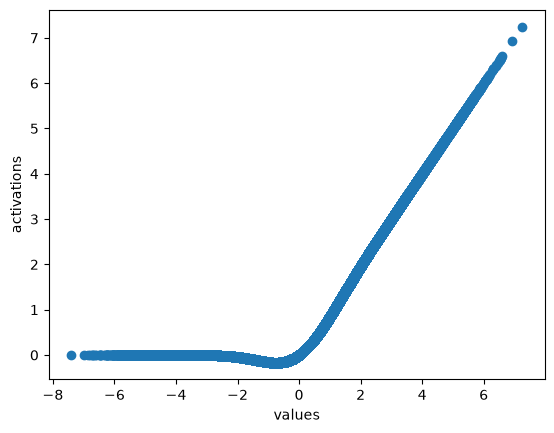

In [35]:
import matplotlib.pyplot as plt

xs = inputs_embeddings.flatten()
ys = activation_fn(xs)

plt.scatter(
    xs.detach().numpy(),
    ys.detach().numpy(),
    marker="o"
)
plt.xlabel("values")
plt.ylabel("activations")
plt.show()

### FFN

In [36]:
class LayerNormalization(nn.Module):
    def __init__(self, embedding_dim: int):
        super().__init__()
        self.epsilon = 1e-6
        self.scale = nn.Parameter(torch.ones(embedding_dim))
        self.shift = nn.Parameter(torch.zeros(embedding_dim))

    def forward(self, x):
        mean = torch.mean(x, axis=-1, keepdim=True)
        var = torch.var(x, axis=-1, keepdim=True)
        norm = (x - mean) / torch.sqrt(var + self.epsilon)
        return self.scale * norm + self.shift

In [37]:
norm = LayerNormalization(cfg["emb_dim"])
norm

LayerNormalization()

In [38]:
torch.allclose(norm(inputs_embeddings).sum(axis=-1), torch.zeros(cfg["batch_size"], cfg["context_length"]), atol=1e-4)

True

In [39]:
class FeedForward(nn.Module):
    def __init__(self, embedding_dim: int):
        super().__init__()
        self.fan_in = nn.Linear(embedding_dim, 4 * embedding_dim)
        self.activation_fn = GELU()
        self.fan_out = nn.Linear(4 * embedding_dim, embedding_dim)

    def forward(self, x):
        x = self.fan_in(x)
        x = self.activation_fn(x)
        x = self.fan_out(x)
        return x

In [40]:
ffn = FeedForward(cfg["emb_dim"])
ffn

FeedForward(
  (fan_in): Linear(in_features=768, out_features=3072, bias=True)
  (activation_fn): GELU()
  (fan_out): Linear(in_features=3072, out_features=768, bias=True)
)

In [41]:
ffn(inputs_embeddings)

tensor([[[ 0.0544, -0.2679, -0.2454,  ...,  0.0181,  0.5934,  0.6076],
         [ 0.0250, -0.2644,  0.1441,  ..., -0.0100, -0.0085,  0.3349],
         [ 0.0840,  0.1893,  0.1190,  ...,  0.1440, -0.1841,  0.3256],
         ...,
         [-0.0771,  0.1454, -0.0912,  ...,  0.2833, -0.6161, -0.2122],
         [-0.2142, -0.2672,  0.2147,  ..., -0.0750,  0.1126,  0.0828],
         [-0.2206, -0.2496, -0.1666,  ..., -0.0878,  0.1162, -0.2130]],

        [[-0.6997, -0.4039, -0.0434,  ...,  0.0629,  0.1392,  0.3588],
         [ 0.0148,  0.0772,  0.0251,  ...,  0.2259,  0.1775,  0.0969],
         [-0.1510,  0.2653,  0.2260,  ...,  0.2417, -0.1475,  0.2407],
         ...,
         [-0.0270,  0.1052,  0.2370,  ...,  0.4358, -0.4030,  0.2196],
         [-0.3966,  0.0127, -0.0383,  ...,  0.3260, -0.2798,  0.0999],
         [ 0.2102, -0.6138, -0.4007,  ...,  0.1623,  0.2184, -0.2851]],

        [[-0.1910, -0.3567, -0.2688,  ...,  0.0840,  0.1438,  0.3347],
         [-0.1298,  0.3313,  0.0754,  ..., -0

### Transformer block

In [42]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["hid_dim"],
            d_out=cfg["hid_dim"],
            context_len=cfg["context_length"],
            n_heads=cfg["n_heads"],
            qkv_bias=cfg["qkv_bias"],
            drop_rate=cfg["drop_rate"]
        )
        self.ff = FeedForward(cfg["hid_dim"])
        self.norm1 = LayerNormalization(cfg["hid_dim"])
        self.norm2 = LayerNormalization(cfg["hid_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x

In [43]:
trf = TransformerBlock(cfg)
trf

TransformerBlock(
  (att): MultiHeadAttention(
    (W_query): Linear(in_features=768, out_features=768, bias=False)
    (W_key): Linear(in_features=768, out_features=768, bias=False)
    (W_value): Linear(in_features=768, out_features=768, bias=False)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=768, bias=True)
  )
  (ff): FeedForward(
    (fan_in): Linear(in_features=768, out_features=3072, bias=True)
    (activation_fn): GELU()
    (fan_out): Linear(in_features=3072, out_features=768, bias=True)
  )
  (norm1): LayerNormalization()
  (norm2): LayerNormalization()
  (drop_shortcut): Dropout(p=0.1, inplace=False)
)

In [44]:
trf(inputs_embeddings)

tensor([[[ 1.2622e+00, -1.1895e+00, -3.2691e-01,  ...,  5.1375e-01,
           1.0918e+00,  4.5128e-01],
         [ 5.5627e-01,  5.8073e-01, -2.3800e-01,  ..., -2.1185e+00,
          -6.6345e-01,  9.3913e-01],
         [-1.6314e-01,  3.9188e+00, -2.5392e-01,  ..., -3.7336e+00,
          -2.4697e+00, -3.7894e-01],
         ...,
         [ 5.7889e-01,  1.7304e+00, -1.1826e+00,  ..., -1.1211e+00,
           9.7041e-01, -1.1792e+00],
         [-1.6449e+00, -9.4255e-01, -1.6567e+00,  ...,  1.6350e+00,
          -4.7991e-01,  1.2864e+00],
         [-8.7687e-01,  9.8124e-01,  2.0705e+00,  ...,  1.1994e+00,
          -9.4505e-01, -1.2435e-01]],

        [[ 2.2400e+00, -1.1040e+00,  2.0203e-01,  ...,  3.9765e-02,
           1.6370e+00,  1.0301e-01],
         [ 1.8932e+00,  1.6743e-01, -1.1200e-01,  ..., -6.3558e-01,
          -2.5884e+00,  3.7366e-02],
         [ 1.7701e+00,  9.4475e-01, -4.1515e-01,  ..., -3.1554e+00,
          -2.3274e+00, -7.9590e-01],
         ...,
         [-1.7893e+00,  5

### Training

In [45]:
from tqdm import tqdm

class LLM(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(p=cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg)
            for _ in range(cfg["n_layers"])]
        )
        self.final_norm = LayerNormalization(cfg["hid_dim"])
        self.out_head = nn.Linear(cfg["hid_dim"], cfg["vocab_size"])

    def forward(self, ids: torch.Tensor):
        b, seq_len = ids.shape

        x = self.pos_emb(torch.arange(0, seq_len, device=ids.device)) + self.tok_emb(ids)
        x = self.drop_emb(x)
        x = self.trf_blocks(x)

        return self.out_head(self.final_norm(x))

llm = LLM(cfg).to(DEVICE)

total_params_all = sum(p.numel() for p in llm.parameters())
total_params_no_proj = total_params_all - sum(p.numel() for p in llm.out_head.parameters())

def to_gb(params, dtype: str = "float32"):
    if dtype == "float32":
        bytes = params * 4
    elif dtype == "float16":
        bytes = params * 2
    else:
        bytes = params
    gb = bytes / (1024**3)
    return gb

print(
    "Characteristics:\n"
    "\tAll:\n"
    f"\t\tParams = {total_params_all//(10**6)}M\n"
    f"\t\tMemory = {to_gb(total_params_all):.2f}Gb\n"
    "\tNo output projection:\n"
    f"\t\tParams = {total_params_no_proj//(10**6)}M\n"
    f"\t\tMemory = {to_gb(total_params_no_proj):.2f}Gb\n"
)

Characteristics:
	All:
		Params = 163M
		Memory = 0.61Gb
	No output projection:
		Params = 124M
		Memory = 0.46Gb



In [ ]:
if FILE.exists():
    llm.load_state_dict(torch.load(FILE, map_location=DEVICE))
    llm.eval()
else:
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(llm.parameters(), lr=1e-3)
    with open('the-verdict.txt', mode='r', encoding='utf-8') as f:
        text = f.read()

    epoch_losses = []
    epoch_loss_prev = None

    llm.train()
    for epoch in range(1, 100 + 1):
        step_losses = []
        for inputs_ids, target_ids in tqdm(create_dataloader(text, batch_size=cfg["batch_size"], max_len=cfg["context_length"], stride=cfg["context_length"] // 2, shuffle=True), desc="Processing training examples", unit="batch"):
            optimizer.zero_grad()
            logits = llm(inputs_ids)
            step_loss = loss_fn(logits.flatten(0, 1), target_ids.flatten())
            step_loss.backward()
            step_losses.append(step_loss)
            optimizer.step()
        epoch_loss_curr = torch.mean(torch.tensor(step_losses)).item()
        print(f"Epoch {epoch}: {epoch_loss_curr:.4f}")
        if epoch_loss_prev is not None and len(epoch_losses) > 5:
            if abs(epoch_loss_prev - epoch_loss_curr) < 0.05:
                print(f"Early stopping, loss diff is less than 0.05 between last epochs")
                break
        epoch_losses.append(epoch_loss_curr)
        epoch_loss_prev = epoch_loss_curr
    torch.save(llm.state_dict(), FILE)

Processing training examples: 100%|██████████| 2/2 [00:22<00:00, 11.07s/batch]


Epoch 1: 10.2862


Processing training examples:  50%|█████     | 1/2 [00:09<00:09,  9.58s/batch]

### Inference

In [ ]:
answer_length = 64
text = "The best you could do is"
token_ids = tokenizer.encode(text, allowed_special={TOK_EOT})
while len(token_ids) < cfg["context_length"] and len(token_ids) < answer_length:
    input_ids = torch.tensor(token_ids).unsqueeze(0)
    with torch.no_grad():
        logits = llm(input_ids)
    next_logits = logits[0, -1, :]
    next_probs = torch.softmax(next_logits, dim=-1)
    next_token_id = torch.multinomial(next_probs, num_samples=1).item()
    if next_token_id == TOK_ID_EOT:
        break
    token_ids.append(next_token_id)
text = tokenizer.decode(token_ids)
text